# FASE 2 - ANÁLISE DOS INDICADORES

## Objetivo

Compreender o comportamento dos indicadores educacionais da Passos Mágicos e responder às perguntas de negócio propostas no Datathon.

## Indicadores analisados

- IAN (Indicador de Adequação ao Nível)
- IDA (Indicador de Aprendizagem)
- IEG (Indicador de Engajamento)
- IAA (Indicador de Auto Avaliação)
- IPS (Indicador Psicossocial)
- IPP (Indicador Psicopedagógico)
- IPV (Indicador de Ponto de Virada)
- INDE (Índice de Desenvolvimento Educacional)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
from google.colab import files

uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [5]:
xls = pd.ExcelFile(arquivo)

print(xls.sheet_names)

['PEDE2022', 'PEDE2023', 'PEDE2024']


In [6]:
df2022 = pd.read_excel(arquivo, sheet_name='PEDE2022')
df2023 = pd.read_excel(arquivo, sheet_name='PEDE2023')
df2024 = pd.read_excel(arquivo, sheet_name='PEDE2024')

print("Bases carregadas com sucesso!")

Bases carregadas com sucesso!


# Roadmap da Fase 2

Perguntas do Datathon:

- [ ] Pergunta 1 - Adequação ao Nível (IAN)
- [ ] Pergunta 2 - Desempenho Acadêmico (IDA)
- [ ] Pergunta 3 - Engajamento (IEG)
- [ ] Pergunta 4 - Autoavaliação (IAA)
- [ ] Pergunta 5 - Aspectos Psicossociais (IPS)
- [ ] Pergunta 6 - Aspectos Psicopedagógicos (IPP)
- [ ] Pergunta 7 - Ponto de Virada (IPV)
- [ ] Pergunta 8 - Multidimensionalidade dos Indicadores (INDE)

Status: Não iniciado.

# Pergunta 1 - Adequação ao Nível (IAN)

Análise será iniciada na próxima sessão.

Descobertas iniciais da auditoria:

- IAN possui apenas 3 categorias: 2.5, 5.0 e 10.0.
- 622 alunos possuem IAN = 10.
- 531 alunos possuem IAN = 5.
- 3 alunos possuem IAN = 2.5.
- O indicador se comporta como classificação e não como variável contínua.

In [7]:
df2024['Defasagem'].describe()

,Defasagem
count,1156.000000
mean,-0.409170
std,0.850497
min,-3.000000
25%,-1.000000
50%,0.000000
75%,0.000000
max,3.000000


In [8]:
df2024['Defasagem'].value_counts().sort_index()

,count
Defasagem,
-3,3
-2,90
-1,441
0,485
1,119
2,16
3,2


In [9]:
pd.crosstab(
    df2024['IAN'],
    df2024['Defasagem']
)

Defasagem,-3,-2,-1,0,1,2,3
IAN,,,,,,,
2.5,3,0,0,0,0,0,0
5.0,0,90,441,0,0,0,0
10.0,0,0,0,485,119,16,2


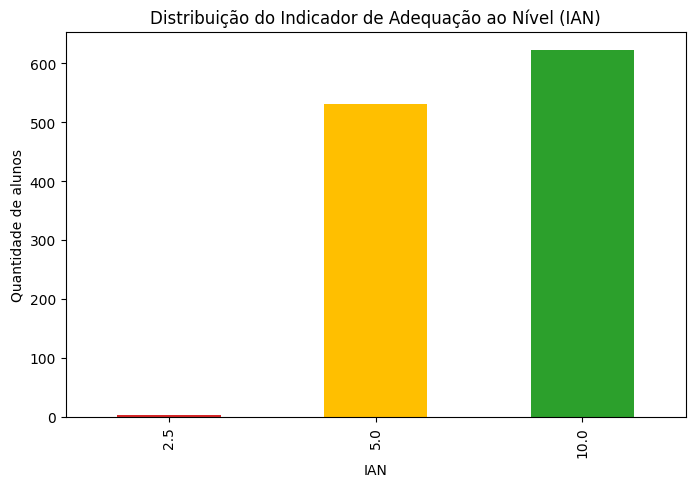

In [10]:
import matplotlib.pyplot as plt

ian_counts = df2024['IAN'].value_counts().sort_index()

plt.figure(figsize=(8,5))

ian_counts.plot(
    kind='bar',
    color=['#d62728', '#ffbf00', '#2ca02c']
)

plt.title('Distribuição do Indicador de Adequação ao Nível (IAN)')
plt.xlabel('IAN')
plt.ylabel('Quantidade de alunos')

plt.show()

In [11]:
(
    df2024['IAN']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

,proportion
IAN,
2.5,0.26
5.0,45.93
10.0,53.81


# Conclusões - Pergunta 1 (IAN)

## O que é o IAN

O Indicador de Adequação ao Nível (IAN) mede se o aluno está na fase educacional esperada em relação ao seu estágio de desenvolvimento.

---

## Distribuição dos alunos em 2024

| IAN | Percentual |
|------|------:|
| 2.5 | 0,26% |
| 5.0 | 45,93% |
| 10.0 | 53,81% |

---

## Relação entre IAN e Defasagem

Foi identificada uma relação direta entre IAN e Defasagem.

### IAN = 10

Representa alunos na fase ideal ou acima da fase ideal.

Defasagem:

- 0
- 1
- 2
- 3

Quantidade:

622 alunos.

---

### IAN = 5

Representa alunos abaixo da fase ideal.

Defasagem:

- -1
- -2

Quantidade:

531 alunos.

---

### IAN = 2.5

Representa alunos com forte defasagem.

Defasagem:

- -3

Quantidade:

3 alunos.

---

## Insight Executivo

Aproximadamente 46% dos alunos apresentam algum grau de defasagem em relação à fase ideal, enquanto 54% encontram-se adequados ou acima do nível esperado.

A adequação ao nível representa um importante indicador de acompanhamento pedagógico e pode ser utilizada para priorizar ações de suporte educacional.

In [12]:
df2024.groupby('IAN')['IDA'].agg(
    ['count','mean','median','std']
).round(2)

,count,mean,median,std
IAN,,,,
2.5,3,5.67,6.67,2.18
5.0,531,6.22,6.50,2.11
10.0,521,6.49,7.00,2.15


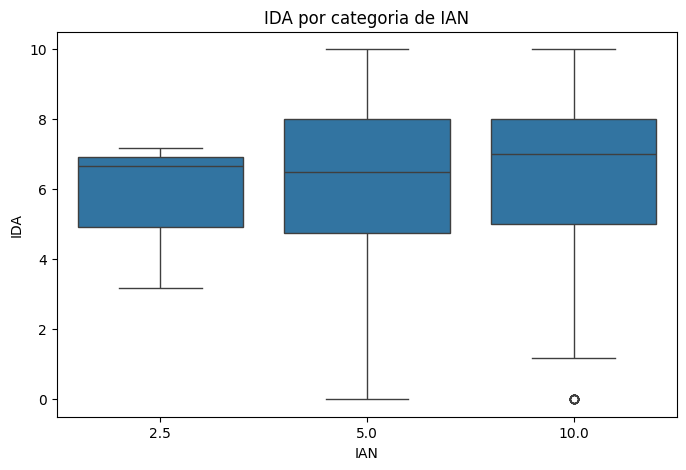

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df2024,
    x='IAN',
    y='IDA'
)

plt.title('IDA por categoria de IAN')
plt.show()

## Relação entre IAN e IDA

Foi observada uma tendência positiva entre Adequação ao Nível (IAN) e Desempenho Acadêmico (IDA).

Médias observadas:

| IAN | Média IDA |
|------|------:|
| 2.5 | 5.67 |
| 5.0 | 6.22 |
| 10.0 | 6.49 |

Apesar da tendência positiva, existe forte sobreposição entre os grupos, indicando que a adequação ao nível não explica sozinha o desempenho acadêmico.

### Insight Executivo

Alunos adequados ao nível esperado apresentam melhor desempenho médio, porém fatores adicionais além da adequação ao nível parecem influenciar significativamente os resultados acadêmicos.

# Pergunta 2 - Desempenho Acadêmico (IDA)

Objetivo:

Compreender o comportamento do Indicador de Aprendizagem (IDA), identificar fatores associados ao desempenho acadêmico e avaliar sua evolução.


In [14]:
df2024['IDA'].describe()

,IDA
count,1055.000000
mean,6.351422
std,2.131639
min,0.000000
25%,4.916667
50%,6.750000
75%,8.000000
max,10.000000


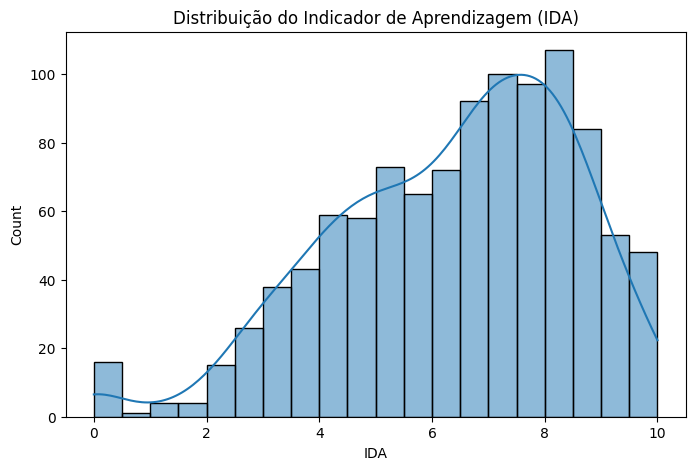

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['IDA'],
    bins=20,
    kde=True
)

plt.title('Distribuição do Indicador de Aprendizagem (IDA)')
plt.show()

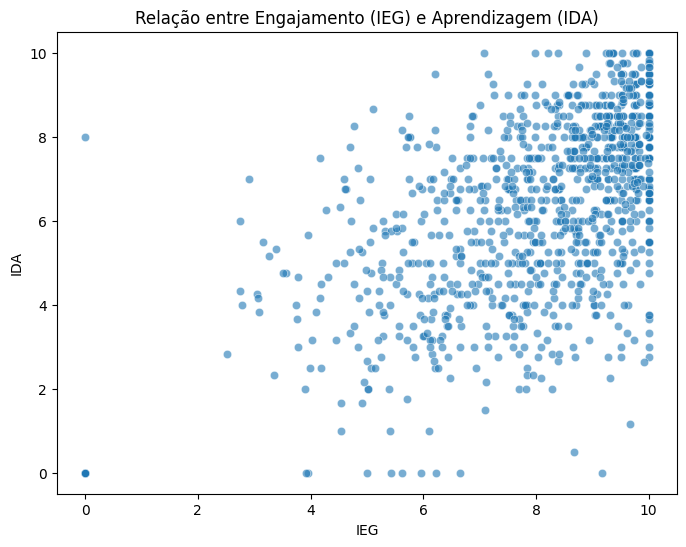

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df2024,
    x='IEG',
    y='IDA',
    alpha=0.6
)

plt.title('Relação entre Engajamento (IEG) e Aprendizagem (IDA)')
plt.show()

In [19]:
df2024[['IEG','IDA']].corr()

,IEG,IDA
IEG,1.000000,0.538411
IDA,0.538411,1.000000


## Relação entre Engajamento (IEG) e Aprendizagem (IDA)

Foi observada uma correlação positiva moderada entre Engajamento (IEG) e Aprendizagem (IDA).

Correlação observada:

r = 0,538

O gráfico de dispersão demonstra que alunos com maiores níveis de engajamento tendem a apresentar melhores resultados acadêmicos.

Embora existam exceções, o padrão geral sugere que o engajamento é um dos fatores associados ao desempenho educacional.

### Insight Executivo

O engajamento dos estudantes demonstra ser um importante fator associado ao sucesso acadêmico. Estratégias voltadas ao aumento da participação e envolvimento dos alunos podem contribuir para melhores resultados de aprendizagem.

In [20]:
df2024['Faixa_IDA'] = pd.cut(
    df2024['IDA'],
    bins=[0,4,7,10],
    labels=[
        'Baixo Desempenho',
        'Desempenho Médio',
        'Alto Desempenho'
    ],
    include_lowest=True
)

df2024['Faixa_IDA'].value_counts()

,count
Faixa_IDA,
Alto Desempenho,446
Desempenho Médio,438
Baixo Desempenho,171


In [21]:
df2024.groupby('Faixa_IDA')[
    ['IEG','IAA','IPS','IPP','IPV']
].mean().round(2)

/tmp/ipykernel_1639/3303610846.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2024.groupby('Faixa_IDA')[


,IEG,IAA,IPS,IPP,IPV
Faixa_IDA,,,,,
Baixo Desempenho,6.60,7.94,6.68,7.04,6.54
Desempenho Médio,7.79,8.48,6.87,7.36,7.11
Alto Desempenho,8.93,8.84,6.85,7.93,7.90


## Comparação entre faixas de desempenho

Os alunos foram agrupados em três categorias:

- Baixo Desempenho
- Desempenho Médio
- Alto Desempenho

Principais resultados:

| Indicador | Baixo | Médio | Alto |
|------------|------:|------:|------:|
| IEG | 6.60 | 7.79 | 8.93 |
| IAA | 7.94 | 8.48 | 8.84 |
| IPS | 6.68 | 6.87 | 6.85 |
| IPP | 7.04 | 7.36 | 7.93 |
| IPV | 6.54 | 7.11 | 7.90 |

### Insight Executivo

O engajamento (IEG) apresentou a diferença mais expressiva entre os grupos de desempenho, indicando forte associação com os resultados acadêmicos.

Também foram observados aumentos consistentes nos indicadores psicopedagógicos (IPP) e no Ponto de Virada (IPV), sugerindo que esses fatores estão relacionados ao sucesso acadêmico dos estudantes.

In [22]:
corr_ida = (
    df2024[['IDA','IEG','IAA','IPS','IPP','IPV']]
    .corr()['IDA']
    .sort_values(ascending=False)
)

corr_ida

,IDA
IDA,1.000000
IEG,0.538411
IPV,0.513745
IPP,0.395288
IAA,0.219653
IPS,0.014494


## Indicadores mais associados ao desempenho acadêmico

Correlação dos indicadores com IDA:

| Indicador | Correlação |
|------------|------:|
| IEG | 0.538 |
| IPV | 0.514 |
| IPP | 0.395 |
| IAA | 0.220 |
| IPS | 0.014 |

### Insight Executivo

O Engajamento (IEG) foi o fator mais associado ao desempenho acadêmico dos estudantes.

Também foram observadas associações relevantes com o Indicador de Ponto de Virada (IPV) e o Indicador Psicopedagógico (IPP).

Os resultados sugerem que ações voltadas para aumentar o engajamento e fortalecer o acompanhamento psicopedagógico podem contribuir para melhores resultados de aprendizagem.

# Pergunta 3 - Engajamento (IEG)

Objetivo:

Compreender o comportamento do Indicador de Engajamento (IEG) e identificar sua relação com os demais indicadores.

In [23]:
df2024['IEG'].describe()

,IEG
count,1156.000000
mean,7.374988
std,2.846899
min,0.000000
25%,6.464334
50%,8.333333
75%,9.438567
max,10.000000


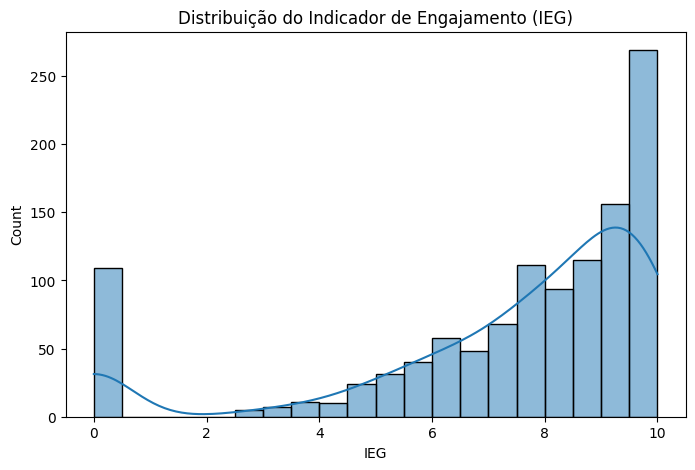

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['IEG'],
    bins=20,
    kde=True
)

plt.title('Distribuição do Indicador de Engajamento (IEG)')
plt.show()


In [25]:
df2024['IEG'].quantile([0.25,0.50,0.75])

,IEG
0.25,6.464334
0.50,8.333333
0.75,9.438567


In [26]:
df2024['Faixa_IEG'] = pd.cut(
    df2024['IEG'],
    bins=[0,5,8,10],
    labels=[
        'Baixo Engajamento',
        'Engajamento Médio',
        'Alto Engajamento'
    ],
    include_lowest=True
)

df2024['Faixa_IEG'].value_counts()

,count
Faixa_IEG,
Alto Engajamento,634
Engajamento Médio,354
Baixo Engajamento,168


In [27]:
df2024.groupby('Faixa_IEG')[
    ['IDA','IAA','IPS','IPP','IPV']
].mean().round(2)

/tmp/ipykernel_1639/2374603713.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2024.groupby('Faixa_IEG')[


,IDA,IAA,IPS,IPP,IPV
Faixa_IEG,,,,,
Baixo Engajamento,3.92,7.75,6.59,6.66,6.04
Engajamento Médio,5.44,8.26,6.82,7.24,6.90
Alto Engajamento,7.12,8.78,6.86,7.81,7.75


/tmp/ipykernel_1639/2689365435.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2024.groupby('Faixa_IEG')['IDA']


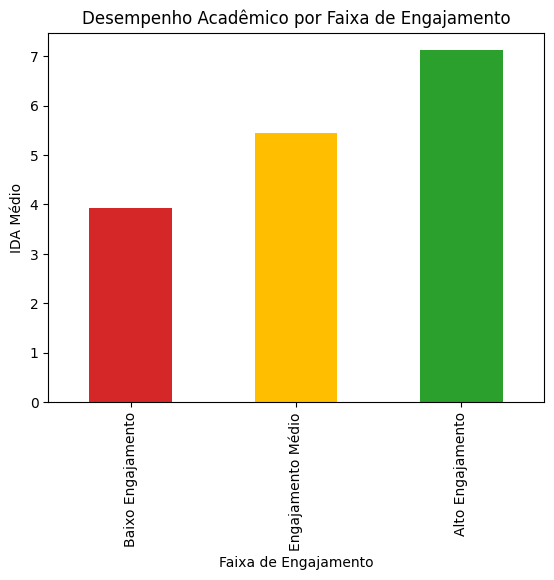

In [28]:
media_faixa_ieg = (
    df2024.groupby('Faixa_IEG')['IDA']
    .mean()
    .round(2)
)

media_faixa_ieg.plot(
    kind='bar',
    color=['#d62728','#ffbf00','#2ca02c']
)

plt.title('Desempenho Acadêmico por Faixa de Engajamento')
plt.ylabel('IDA Médio')
plt.xlabel('Faixa de Engajamento')

plt.show()

In [29]:
media_faixa_ieg

,IDA
Faixa_IEG,
Baixo Engajamento,3.92
Engajamento Médio,5.44
Alto Engajamento,7.12


## Impacto do Engajamento no Desempenho Acadêmico

Os alunos foram agrupados em três níveis de engajamento:

| Faixa de Engajamento | IDA Médio |
|------|------:|
| Baixo Engajamento | 3.92 |
| Engajamento Médio | 5.44 |
| Alto Engajamento | 7.12 |

### Insight Executivo

O engajamento apresentou forte associação com a aprendizagem.

Alunos com alto nível de engajamento apresentaram desempenho acadêmico médio significativamente superior ao grupo de baixo engajamento.

Os resultados sugerem que ações voltadas ao aumento da participação, frequência e envolvimento dos estudantes podem gerar ganhos relevantes nos resultados educacionais.

In [30]:
df2024.groupby('Faixa_IEG')[
    ['IAN','IDA','IAA','IPS','IPP','IPV']
].mean().round(2)

/tmp/ipykernel_1639/300886982.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2024.groupby('Faixa_IEG')[


,IAN,IDA,IAA,IPS,IPP,IPV
Faixa_IEG,,,,,,
Baixo Engajamento,8.78,3.92,7.75,6.59,6.66,6.04
Engajamento Médio,7.27,5.44,8.26,6.82,7.24,6.90
Alto Engajamento,7.63,7.12,8.78,6.86,7.81,7.75


In [31]:
pd.crosstab(
    df2024['Faixa_IEG'],
    df2024['IAN'],
    normalize='index'
).round(3) * 100

IAN,2.5,5.0,10.0
Faixa_IEG,,,
Baixo Engajamento,0.0,24.4,75.6
Engajamento Médio,0.8,53.4,45.8
Alto Engajamento,0.0,47.5,52.5


In [32]:
corr_ieg = (
    df2024[['IEG','IAN','IDA','IAA','IPS','IPP','IPV']]
    .corr()['IEG']
    .sort_values(ascending=False)
)

corr_ieg

,IEG
IEG,1.000000
IDA,0.538411
IPV,0.535287
IPP,0.408772
IAA,0.230092
IPS,0.060655
IAN,-0.187464


## Indicadores mais associados ao Engajamento (IEG)

Correlação dos indicadores com IEG:

| Indicador | Correlação |
|-----------|----------:|
| IDA | 0.538 |
| IPV | 0.535 |
| IPP | 0.409 |
| IAA | 0.230 |
| IPS | 0.061 |
| IAN | -0.187 |

### Insight Executivo

O Engajamento apresentou forte associação com Aprendizagem (IDA), Ponto de Virada (IPV) e Indicador Psicopedagógico (IPP).

Os resultados sugerem que estudantes mais engajados tendem a apresentar melhores resultados acadêmicos e maior desenvolvimento educacional.

O engajamento aparece como uma das dimensões mais relevantes do desenvolvimento dos alunos analisados.

# Pergunta 4 - Autoavaliação (IAA)

Objetivo:

Analisar o comportamento da autoavaliação dos estudantes e verificar sua relação com o desempenho acadêmico e demais indicadores.

In [33]:
df2024['IAA'].describe()

,IAA
count,1054.000000
mean,8.543563
std,1.491450
min,0.000000
25%,8.002000
50%,8.751000
75%,9.502000
max,10.002000


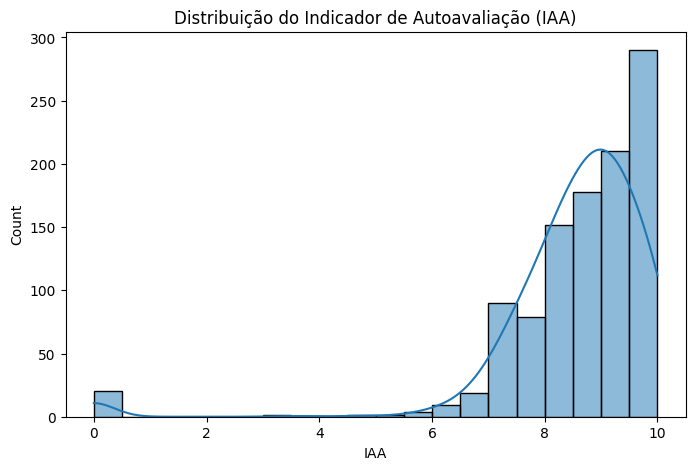

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['IAA'],
    bins=20,
    kde=True
)

plt.title('Distribuição do Indicador de Autoavaliação (IAA)')
plt.show()

In [35]:
df2024['IAA'].quantile([0.25,0.50,0.75])


,IAA
0.25,8.002
0.50,8.751
0.75,9.502


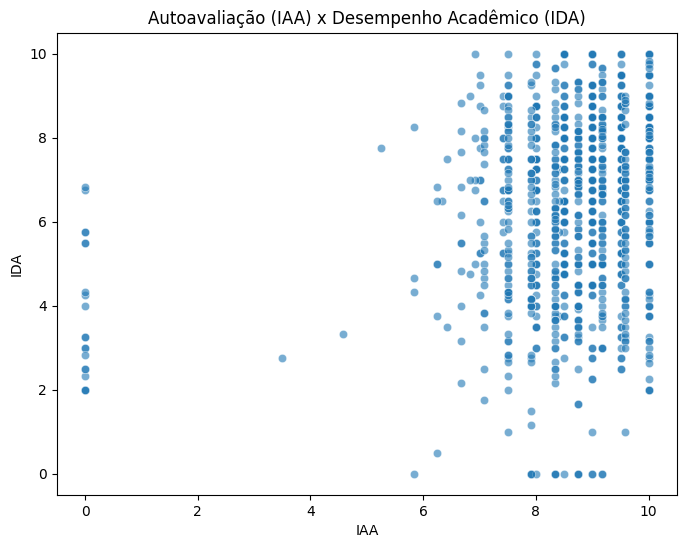

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df2024,
    x='IAA',
    y='IDA',
    alpha=0.6
)

plt.title('Autoavaliação (IAA) x Desempenho Acadêmico (IDA)')
plt.show()

In [37]:
corr_iaa = (
    df2024[['IAA','IAN','IDA','IEG','IPS','IPP','IPV']]
    .corr()['IAA']
    .sort_values(ascending=False)
)

corr_iaa

,IAA
IAA,1.000000
IEG,0.230092
IDA,0.219653
IPV,0.148351
IPP,0.114016
IAN,0.019258
IPS,-0.005994


In [38]:
df2024['Faixa_IAA'] = pd.cut(
    df2024['IAA'],
    bins=[0,7,9,10.1],
    labels=[
        'Baixa Autoavaliação',
        'Autoavaliação Média',
        'Alta Autoavaliação'
    ],
    include_lowest=True
)

df2024['Faixa_IAA'].value_counts()

,count
Faixa_IAA,
Alta Autoavaliação,500
Autoavaliação Média,499
Baixa Autoavaliação,55


In [39]:
df2024.groupby('Faixa_IAA')[
    ['IDA','IEG','IPS','IPP','IPV']
].mean().round(2)

/tmp/ipykernel_1639/3142608649.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2024.groupby('Faixa_IAA')[


,IDA,IEG,IPS,IPP,IPV
Faixa_IAA,,,,,
Baixa Autoavaliação,4.98,6.93,6.88,7.21,6.84
Autoavaliação Média,6.11,7.88,6.81,7.49,7.29
Alta Autoavaliação,6.74,8.43,6.84,7.64,7.47


## Comparação entre níveis de Autoavaliação

| Indicador | Baixa | Média | Alta |
|------------|------:|------:|------:|
| IDA | 4.98 | 6.11 | 6.74 |
| IEG | 6.93 | 7.88 | 8.43 |
| IPS | 6.88 | 6.81 | 6.84 |
| IPP | 7.21 | 7.49 | 7.64 |
| IPV | 6.84 | 7.29 | 7.47 |

### Insight Executivo

A autoavaliação apresentou associação positiva com os principais indicadores educacionais.

Alunos com maior percepção positiva sobre si mesmos tendem a apresentar melhores resultados acadêmicos, maior engajamento e melhores índices de desenvolvimento.

Apesar disso, o engajamento demonstrou impacto mais expressivo sobre a aprendizagem do que a autoavaliação.

# Pergunta 5 - Aspectos Psicossociais (IPS)

Objetivo:

Analisar o comportamento do Indicador Psicossocial (IPS) e sua relação com os demais indicadores educacionais.

In [40]:
df2024['IPS'].describe()

,IPS
count,1054.000000
mean,6.829670
std,1.427893
min,2.510000
25%,6.260000
50%,7.510000
75%,7.510000
max,10.000000


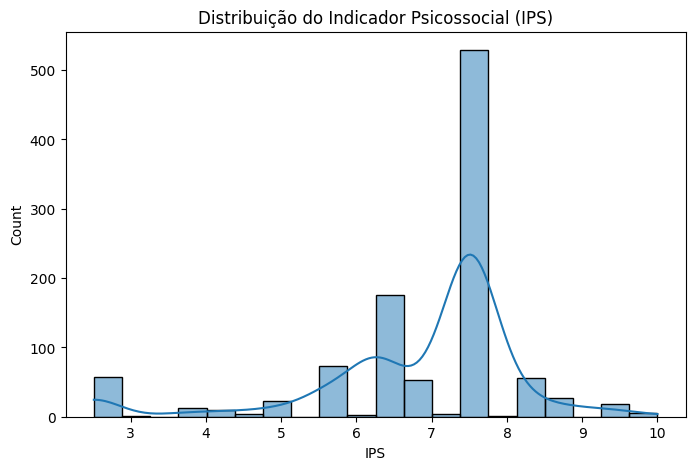

In [41]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['IPS'],
    bins=20,
    kde=True
)

plt.title('Distribuição do Indicador Psicossocial (IPS)')
plt.show()

In [42]:
df2024['IPS'].quantile([0.25,0.50,0.75])

,IPS
0.25,6.26
0.50,7.51
0.75,7.51


In [43]:
corr_ips = (
    df2024[['IPS','IAN','IDA','IEG','IAA','IPP','IPV']]
    .corr()['IPS']
    .sort_values(ascending=False)
)

corr_ips

,IPS
IPS,1.000000
IPP,0.213784
IPV,0.105275
IAN,0.067866
IEG,0.060655
IDA,0.014494
IAA,-0.005994


## Conclusões sobre o IPS

O Indicador Psicossocial apresentou baixa correlação com os demais indicadores educacionais.

Correlações observadas:

| Indicador | Correlação |
|------------|------:|
| IPP | 0.214 |
| IPV | 0.105 |
| IAN | 0.068 |
| IEG | 0.061 |
| IDA | 0.014 |
| IAA | -0.006 |

### Insight Executivo

Os aspectos psicossociais parecem representar uma dimensão complementar do acompanhamento dos estudantes.

Embora apresentem pouca associação direta com desempenho acadêmico e engajamento, podem contribuir para uma visão mais completa do desenvolvimento do aluno.

# Pergunta 6 - Aspectos Psicopedagógicos (IPP)

Objetivo:

Avaliar a relação entre os aspectos psicopedagógicos dos estudantes e os demais indicadores educacionais.

In [44]:
df2024['IPP'].describe()

,IPP
count,1054.000000
mean,7.548303
std,0.897219
min,2.500000
25%,7.187500
50%,7.500000
75%,8.125000
max,10.000000


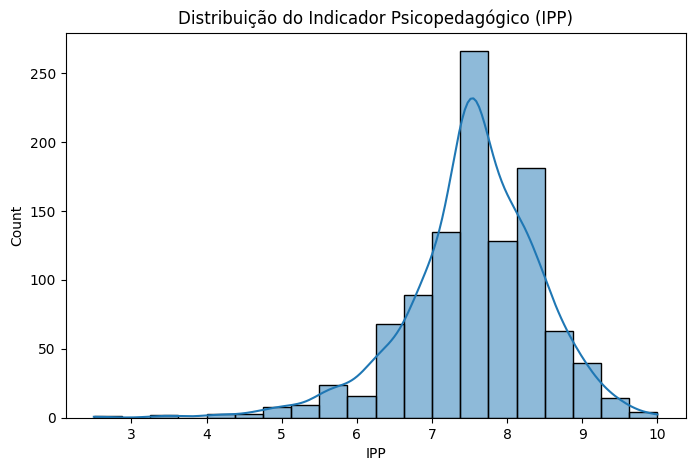

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['IPP'],
    bins=20,
    kde=True
)

plt.title('Distribuição do Indicador Psicopedagógico (IPP)')
plt.show()

In [46]:
df2024['IPP'].quantile([0.25,0.50,0.75])

,IPP
0.25,7.1875
0.50,7.5000
0.75,8.1250


In [47]:
corr_ipp = (
    df2024[['IPP','IAN','IDA','IEG','IAA','IPS','IPV']]
    .corr()['IPP']
    .sort_values(ascending=False)
)

corr_ipp

,IPP
IPP,1.000000
IPV,0.750088
IEG,0.408772
IDA,0.395288
IPS,0.213784
IAN,0.153873
IAA,0.114016


## Indicadores mais associados ao IPP

Correlação dos indicadores com IPP:

| Indicador | Correlação |
|------------|------:|
| IPV | 0.75 |
| IEG | 0.41 |
| IDA | 0.40 |
| IPS | 0.21 |
| IAN | 0.15 |
| IAA | 0.11 |

### Insight Executivo

O Indicador Psicopedagógico (IPP) apresentou a maior associação observada em toda a base com o Indicador de Ponto de Virada (IPV).

Também apresentou relações positivas relevantes com Engajamento (IEG) e Aprendizagem (IDA).

Os resultados sugerem que aspectos psicopedagógicos podem desempenhar papel importante na evolução educacional dos estudantes.

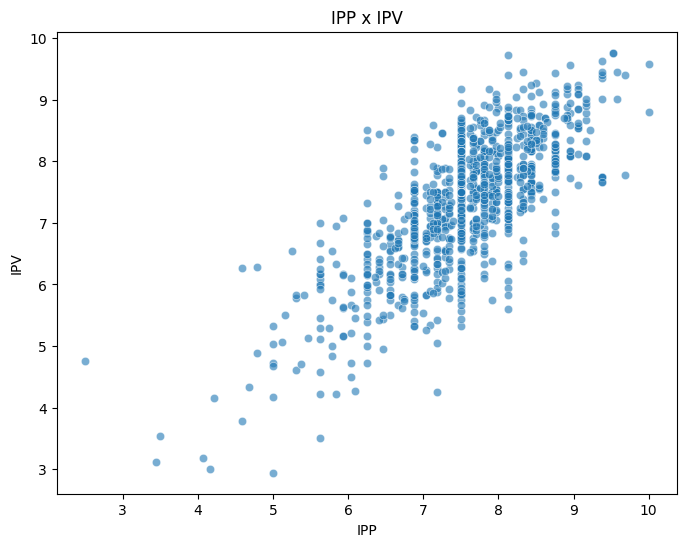

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df2024,
    x='IPP',
    y='IPV',
    alpha=0.6
)

plt.title('IPP x IPV')
plt.show()

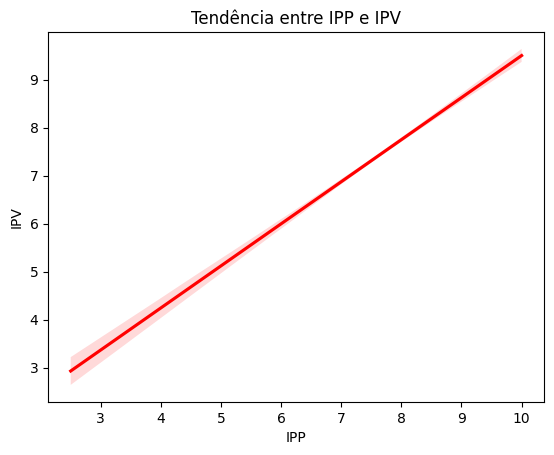

In [49]:
sns.regplot(
    data=df2024,
    x='IPP',
    y='IPV',
    scatter=False,
    color='red'
)

plt.title('Tendência entre IPP e IPV')
plt.show()

# Pergunta 7 - Ponto de Virada (IPV)

Objetivo:

Analisar o comportamento do Indicador de Ponto de Virada (IPV) e identificar os fatores mais associados ao desenvolvimento dos estudantes.

In [50]:
df2024['IPV'].describe()


,IPV
count,1054.000000
mean,7.354268
std,1.048541
min,2.943333
25%,6.790625
50%,7.500000
75%,8.085000
max,9.760000


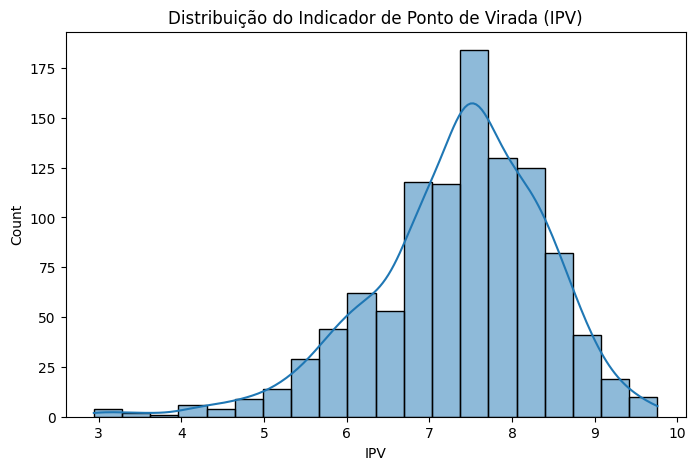

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['IPV'],
    bins=20,
    kde=True
)

plt.title('Distribuição do Indicador de Ponto de Virada (IPV)')
plt.show()

In [53]:
df2024['IPV'].quantile([0.25,0.50,0.75])

,IPV
0.25,6.790625
0.50,7.500000
0.75,8.085000


In [54]:
corr_ipv = (
    df2024[['IPV','IAN','IDA','IEG','IAA','IPS','IPP']]
    .corr()['IPV']
    .sort_values(ascending=False)
)

corr_ipv

,IPV
IPV,1.000000
IPP,0.750088
IEG,0.535287
IDA,0.513745
IAN,0.185067
IAA,0.148351
IPS,0.105275


## Indicadores mais associados ao IPV

Correlação dos indicadores com IPV:

| Indicador | Correlação |
|------------|------:|
| IPP | 0.750 |
| IEG | 0.535 |
| IDA | 0.514 |
| IAN | 0.185 |
| IAA | 0.148 |
| IPS | 0.105 |

### Insight Executivo

O Indicador Psicopedagógico (IPP) apresentou a maior associação com o Ponto de Virada (IPV), sugerindo que fatores psicopedagógicos possuem papel importante no desenvolvimento dos estudantes.

Engajamento (IEG) e Aprendizagem (IDA) também demonstraram relações relevantes com o IPV.

# Pergunta 8 - Multidimensionalidade dos Indicadores (INDE)

Objetivo:

Compreender quais indicadores apresentam maior associação com o Índice de Desenvolvimento Educacional (INDE).

In [55]:
df2024[['INDE 2024']].head()

,INDE 2024
0,7.611367
1,8.002867
2,7.9522
3,7.156367
4,5.4442


In [56]:
df2024['INDE 2024'].dtype

dtype('O')

In [57]:
df2024['INDE 2024'].isnull().sum()

np.int64(64)

In [58]:
df2024['INDE_NUM'] = pd.to_numeric(
    df2024['INDE 2024'],
    errors='coerce'
)

In [59]:
df2024['INDE_NUM'].describe()

,INDE_NUM
count,1054.000000
mean,7.396686
std,1.013915
min,3.789478
25%,6.768097
50%,7.540041
75%,8.139550
max,9.531325


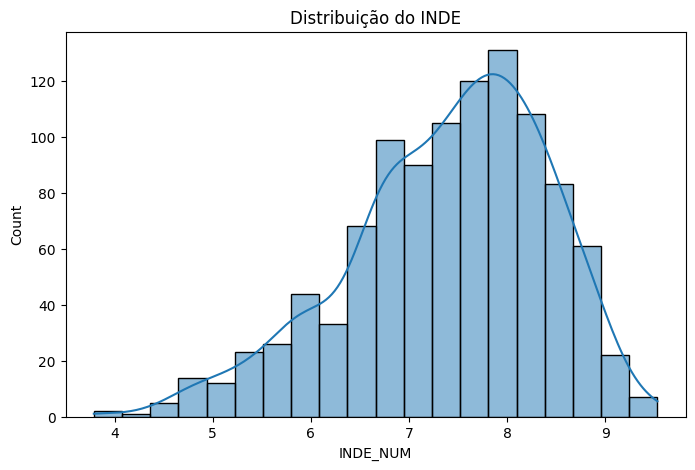

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(
    df2024['INDE_NUM'],
    bins=20,
    kde=True
)

plt.title('Distribuição do INDE')
plt.show()

In [61]:
df2024['INDE_NUM'].quantile([0.25,0.50,0.75])

,INDE_NUM
0.25,6.768097
0.50,7.540041
0.75,8.139550


In [62]:
corr_inde = (
    df2024[['INDE_NUM',
            'IAN',
            'IDA',
            'IEG',
            'IAA',
            'IPS',
            'IPP',
            'IPV']]
    .corr()['INDE_NUM']
    .sort_values(ascending=False)
)

corr_inde

,INDE_NUM
INDE_NUM,1.000000
IDA,0.801985
IEG,0.786891
IPV,0.758006
IPP,0.637097
IAN,0.365568
IAA,0.364233
IPS,0.224651


## Indicadores mais associados ao INDE

Correlação dos indicadores com o Índice de Desenvolvimento Educacional (INDE):

| Indicador | Correlação |
|-----------|------:|
| IDA | 0.802 |
| IEG | 0.787 |
| IPV | 0.758 |
| IPP | 0.637 |
| IAN | 0.366 |
| IAA | 0.364 |
| IPS | 0.225 |

### Insight Executivo

O desempenho acadêmico (IDA), o engajamento (IEG) e o ponto de virada (IPV) foram os indicadores mais associados ao INDE.

Os resultados sugerem que o desenvolvimento educacional dos estudantes depende de uma combinação entre aprendizagem, participação ativa e evolução comportamental.

Os indicadores psicopedagógicos (IPP) também demonstraram papel importante no desenvolvimento dos alunos.